In [1]:
import os
import numpy as np
import xarray as xr
from affine import Affine
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
from osgeo import gdal, osr
import pygmt

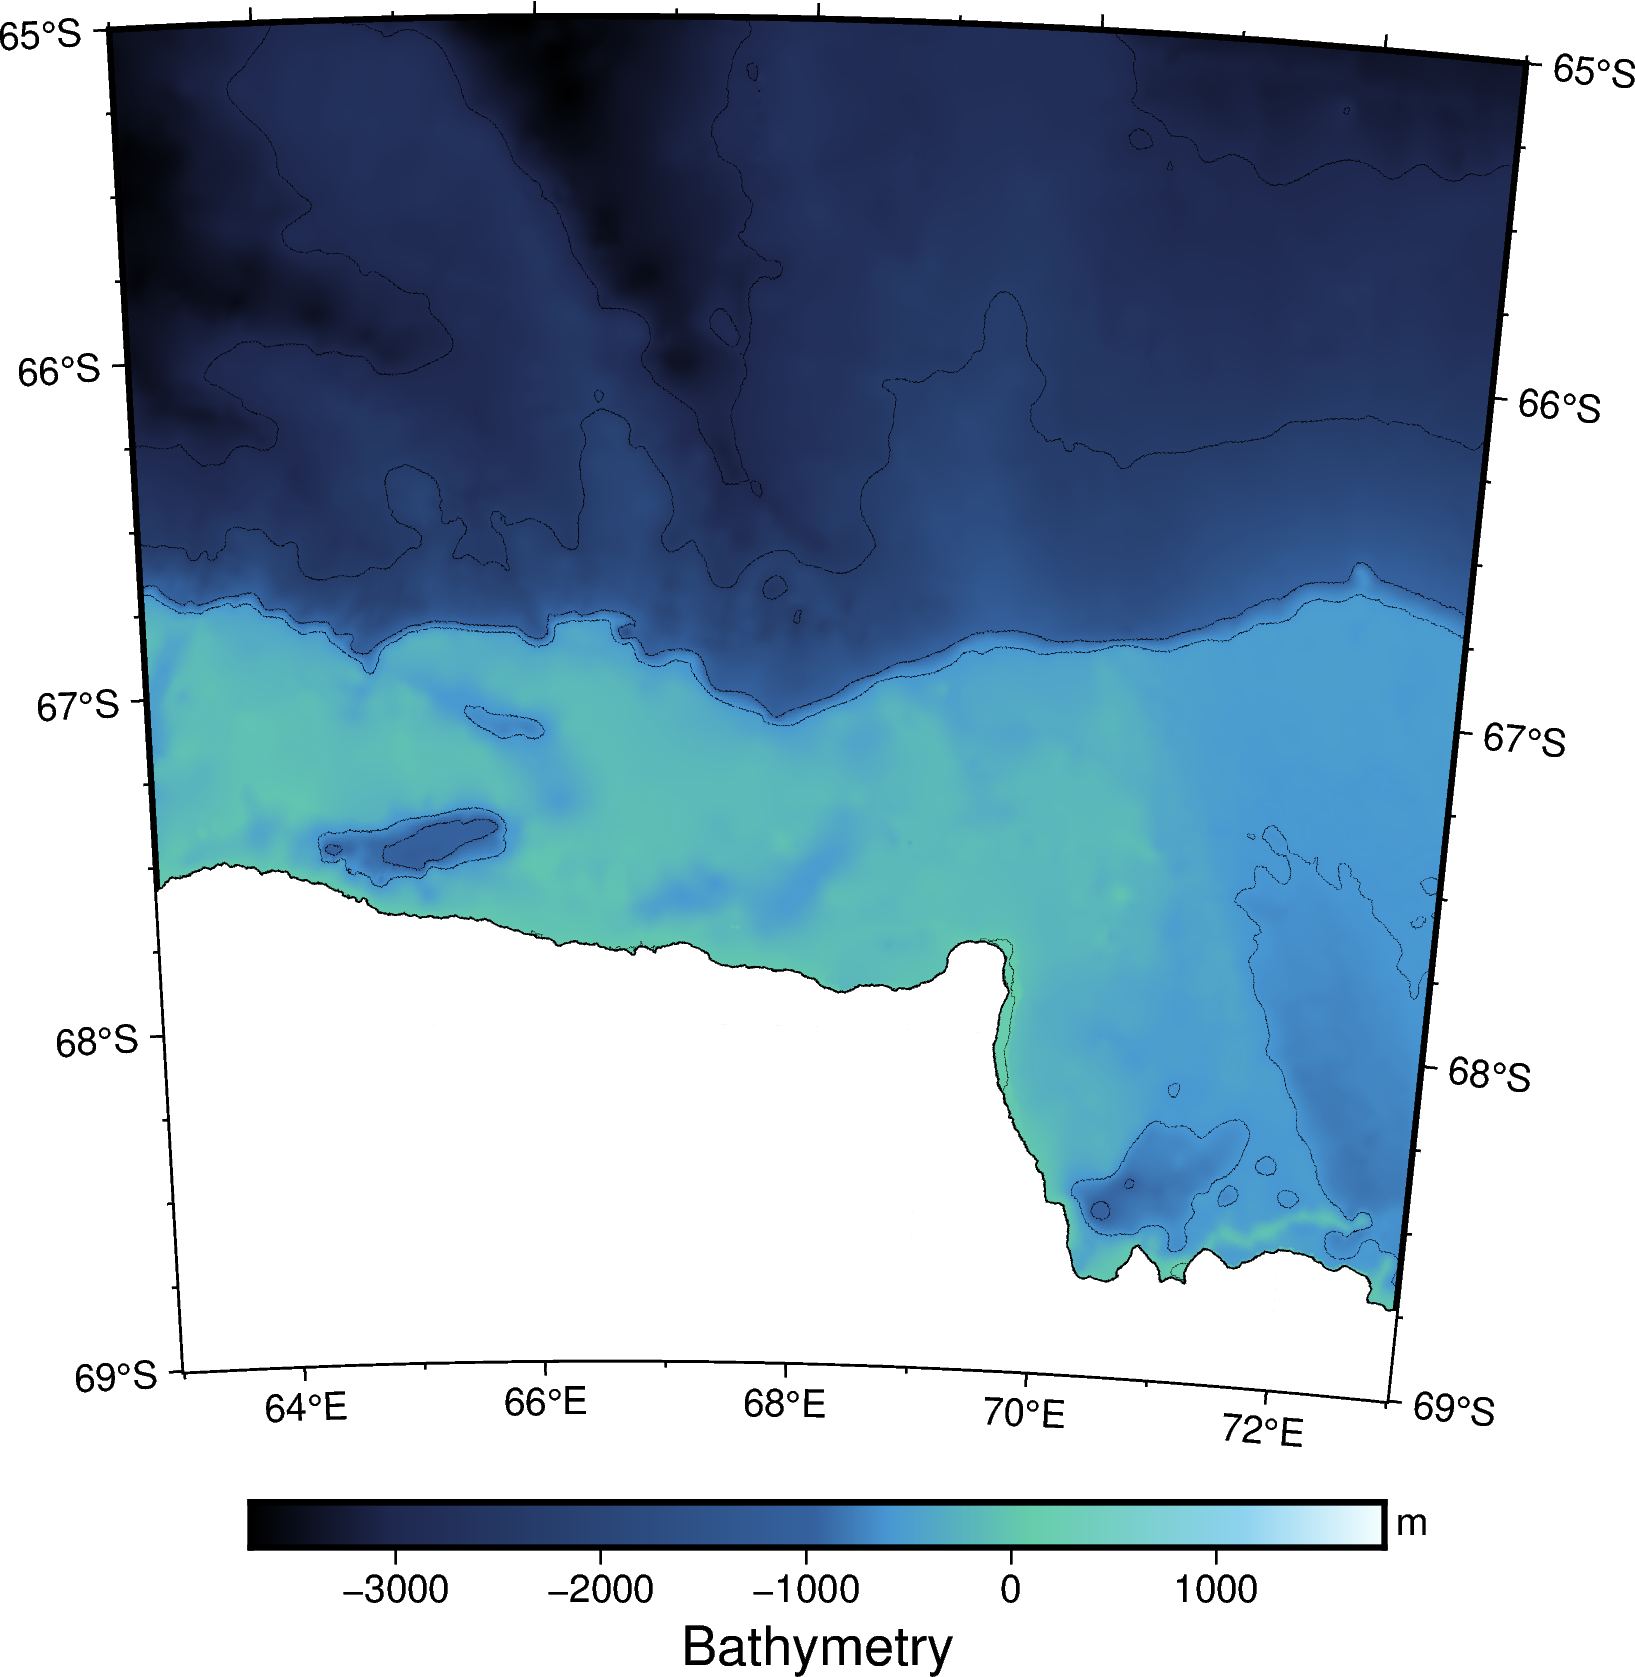

In [2]:
#Fgrd = xr.open_dataset('../GEBCO/gebco_2020_n-63.5_s-75.1_w54.8_e92.8.nc')
fig = pygmt.Figure()
fig.grdview(
    grid='../GEBCO/gebco_2020_n-63.5_s-75.1_w54.8_e92.8.nc',
    # region
    region=[63, 73, -69, -65],
    # Sets the view azimuth as 130 degrees, and the view elevation as 30 degrees
    perspective=[180, 90],
    # Sets the x- and y-axis labels, and annotates the west, south, and east axes
    frame=["xaf", "yaf", "WSnE"],
    # Sets a Mercator projection on a 15-centimeter figure
    projection="C66.5E/67S/12c",#"M10c",#"Oc190/25.5/292/69/16c",
    # Sets the height of the three-dimensional relief at 1.5 centimeters
    #zsize="-5c",
    surftype="s",
    cmap="bathy",
    #plane="10000+ggrey",
    # Set the contour pen thickness to "0.1p"
    contourpen="0.1p",
)
fig.coast(resolution='f',
          land='white',
          shorelines='thinnest')
fig.colorbar(perspective=True,frame=["a1000", "x+lBathymetry", "y+lm"])
fig.show()

In [6]:
fig = pygmt.Figure()
fig.grdview(
    grid="/Volumes/SEASONG/PHD/data/bathy_topo/IBCSO/ibcso_v1_bed.grd",
    # region
    region=[-180, 180, -90, -60],
    # Sets the view azimuth as 130 degrees, and the view elevation as 30 degrees
    perspective=[180, 90],
    # Sets the x- and y-axis labels, and annotates the west, south, and east axes
    frame=["xaf", "yaf", "WSnE"],
    # Sets a Mercator projection on a 15-centimeter figure
    #projection="M20c",
    projection="S0/-90/15c",
    # Sets the height of the three-dimensional relief at 1.5 centimeters
    zsize="-5c",
    surftype="s",
    cmap="bathy",
    #plane="10000+ggrey",
    # Set the contour pen thickness to "0.1p"
    contourpen="0.1p",
)
fig.colorbar(perspective=True,
             frame=["a500", "x+lBathymetry", "y+lm"],
             truncate="-4000/0")
fig.show()

In [ ]:
gdal.UseExceptions()
Ddat  = os.path.join('/','Volumes','SEASONG','PHD','data','bathy_topo','Cape_Darnley_Bathymetry_Grid_v1','03_GEOTIFF')
Fdat  = 'cdbg_v1.tif'

# method one
da    = xr.open_rasterio(os.path.join(Ddat,Fdat))
xfrm  = Affine.from_gdal(*da.variable.attrs['transform'])
nx,ny = da.sizes['x'], da.sizes['y']
x,y   = np.meshgrid(np.arange(nx), np.arange(ny)) * xfrm

# method two
ds = gdal.Open(os.path.join(Ddat,Fdat))
data = ds.ReadAsArray()
gt = ds.GetGeoTransform()
proj = ds.GetProjection()
inproj = osr.SpatialReference()
inproj.ImportFromWkt(proj)
projcs = inproj.GetAuthorityCode('PROJCS')
projection = ccrs.epsg(int(projcs))
subplot_kw = dict(projection=projection)

clevs = np.arange(-3000, 0, 200)
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=subplot_kw)
extent = (gt[0], gt[0] + ds.RasterXSize * gt[1],
          gt[3] + ds.RasterYSize * gt[5], gt[3])
img = ax.imshow(da.variable.data[0], extent=extent, origin='upper', cmap=cmo.ice , vmin=-3000, vmax=0,)
plt.colorbar(img)
ax.coastlines(resolution='10m')#, alpha=0.1)
plt.show()
exit()